In [10]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv(r"C:\Users\KIIT0001\Projects\customer_categoriser\notebook\data\clustered_data.csv") 
df.head()


,Age,Education,Marital Status,Parental Status,Children,Income,Total_Spending,Recency,Wines,Fruits,...,Fish,Sweets,Gold,Web,Catalog,Store,Discount Purchases,Total_Promo,NumWebVisitsMonth,cluster
0,65,2,0,0,0,58138.0,1617,58,635,88,...,172,88,88,8,10,4,3,0,7,1
1,68,2,0,1,2,46344.0,27,38,11,1,...,2,1,6,1,1,2,2,0,5,0
2,57,2,1,0,0,71613.0,776,26,426,49,...,111,21,42,8,2,10,1,0,4,1
3,38,2,1,1,1,26646.0,53,26,11,4,...,10,3,5,2,0,4,2,0,6,0
4,41,4,1,1,1,58293.0,422,94,173,43,...,46,27,15,5,3,6,5,0,5,2


In [5]:
df.isna().sum()

Age                   0
Education             0
Marital Status        0
Parental Status       0
Children              0
Income                0
Total_Spending        0
Recency               0
Wines                 0
Fruits                0
Meat                  0
Fish                  0
Sweets                0
Gold                  0
Web                   0
Catalog               0
Store                 0
Discount Purchases    0
Total_Promo           0
NumWebVisitsMonth     0
cluster               0
dtype: int64

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 2240 non-null   int64  
 1   Education           2240 non-null   int64  
 2   Marital Status      2240 non-null   int64  
 3   Parental Status     2240 non-null   int64  
 4   Children            2240 non-null   int64  
 5   Income              2240 non-null   float64
 6   Total_Spending      2240 non-null   int64  
 7   Recency             2240 non-null   int64  
 8   Wines               2240 non-null   int64  
 9   Fruits              2240 non-null   int64  
 10  Meat                2240 non-null   int64  
 11  Fish                2240 non-null   int64  
 12  Sweets              2240 non-null   int64  
 13  Gold                2240 non-null   int64  
 14  Web                 2240 non-null   int64  
 15  Catalog             2240 non-null   int64  
 16  Store            

In [8]:
 # Assume cluster column is target
x = df.drop("cluster", axis=1)
y = df["cluster"]


In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [20]:
param_grid = [
    {
        "solver": ["liblinear"],
        "penalty": ["l1", "l2"],
        "C": np.logspace(-3, 3, 7),
        "max_iter": [200, 500]
    },
    {
        "solver": ["lbfgs", "newton-cg", "sag"],
        "penalty": ["l2"],
        "C": np.logspace(-3, 3, 7),
        "max_iter": [200, 500],
    },
    {
        "solver": ["saga"],
        "penalty": ["l1", "l2"],
        "C": np.logspace(-3, 3, 7),
        "max_iter": [200, 500]
    }
]

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV



logreg = LogisticRegression()

logreg_cv = GridSearchCV(
    logreg,
    param_grid,
    cv=3,verbose=1,
)

logreg_cv.fit(X_train, y_train)

print("Best Parameters:", logreg_cv.best_params_)
print("Best CV Accuracy:", logreg_cv.best_score_)

Fitting 3 folds for each of 98 candidates, totalling 294 fits
Best Parameters: {'C': np.float64(10.0), 'max_iter': 200, 'penalty': 'l2', 'solver': 'newton-cg'}
Best CV Accuracy: 0.9760032044279368


In [22]:
best_lr_model = LogisticRegression(
    C = 10, 
    max_iter =  200,
    penalty =  'l2', 
    solver =  'newton-cg'
)

In [23]:
best_lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",10
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` 

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("Classification Report:\n", classification_report(y_test, best_lr_model.predict(X_test)))
print("Confusion Matrix:\n", confusion_matrix(y_test, best_lr_model.predict(X_test)))
print("Test Accuracy:", accuracy_score(y_test, best_lr_model.predict(X_test)))  

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99       160
           1       0.99      0.96      0.98       128
           2       0.95      0.99      0.97       160

    accuracy                           0.98       448
   macro avg       0.98      0.98      0.98       448
weighted avg       0.98      0.98      0.98       448

Confusion Matrix:
 [[157   0   3]
 [  0 123   5]
 [  1   1 158]]
Test Accuracy: 0.9776785714285714


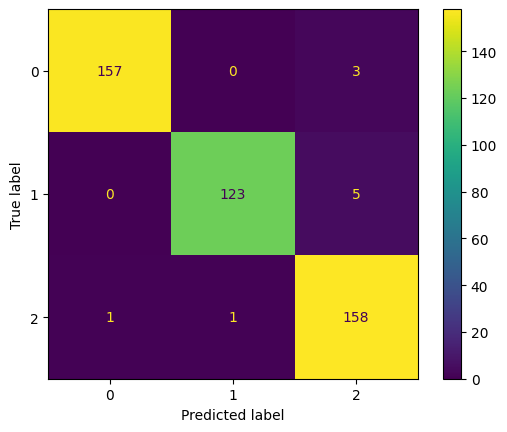

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(best_lr_model, X_test, y_test)